### Bước 1: Khai báo thư viện và cấu hình thư mục

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Tạo các thư mục lưu kết quả nếu chưa có
os.makedirs('processed/duc', exist_ok=True)
os.makedirs('eda/duc/bieu_do_tinh', exist_ok=True)
os.makedirs('eda/duc/bieu_do_tuong_tac', exist_ok=True)

print("Các thư viện đã được nạp thành công!")

Các thư viện đã được nạp thành công!


### Bước 2: Làm sạch dữ liệu nhiệt độ toàn cầu NASA (1880 - 2025)

In [ ]:
# 1. Đọc dữ liệu NASA GISTEMP v4
df_nasa_raw = pd.read_csv('data/raw/01_duc_nhiet_do/nasa_nhiet_do_toan_cau_1880_2026.csv', header=1, na_values='***')

# 2. Giữ lại cột Năm và cột J-D (Độ lệch nhiệt độ trung bình năm)
df_nasa = df_nasa_raw[['Year', 'J-D']].copy()
df_nasa.rename(columns={'Year': 'year', 'J-D': 'temperature_anomaly'}, inplace=True)

# 3. Ép kiểu và lọc năm <= 2025 (loại bỏ năm 2026 vì chưa đủ 12 tháng)
df_nasa['year'] = pd.to_numeric(df_nasa['year'], errors='coerce')
df_nasa['temperature_anomaly'] = pd.to_numeric(df_nasa['temperature_anomaly'], errors='coerce')
df_nasa = df_nasa.dropna(subset=['temperature_anomaly'])
df_nasa = df_nasa[df_nasa['year'] <= 2025].copy()
df_nasa['year'] = df_nasa['year'].astype(int)

# 4. Thêm cột decade
df_nasa['decade'] = (df_nasa['year'] // 10) * 10
df_nasa_final = df_nasa[['year', 'decade', 'temperature_anomaly']].sort_values('year').reset_index(drop=True)

# 5. Xuất ra file CSV
output_nasa = 'processed/duc/nhiet_do_toan_cau.csv'
df_nasa_final.to_csv(output_nasa, index=False)
print(f"Đã xuất file: {output_nasa} ({len(df_nasa_final)} dòng)")
display(df_nasa_final.head())


Đã xuất file: processed/duc/nhiet_do_toan_cau.csv (146 dòng)


,year,decade,temperature_anomaly
0,1880,1880,-0.18
1,1881,1880,-0.09
2,1882,1880,-0.12
3,1883,1880,-0.18
4,1884,1880,-0.29


### Bước 3: Làm sạch & Chuẩn hóa nhiệt độ quốc gia FAOSTAT (1961 - 2025)

In [4]:
# 1. Đọc danh mục mã quốc gia và châu lục từ OWID
df_owid = pd.read_csv('data/raw/04_dung_chung_danh_muc_quoc_gia/owid_quoc_gia_chau_luc.csv')
owid_clean = df_owid.dropna(subset=['Code', 'Entity']).copy()
owid_map = owid_clean.set_index('Entity')[['Code', 'World region according to OWID']].to_dict('index')

# Từ điển chuẩn hóa tên các quốc gia đặc biệt giữa FAOSTAT và OWID
NAME_ALIAS = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Brunei Darussalam': 'Brunei',
    'Cabo Verde': 'Cape Verde',
    'China, Hong Kong SAR': 'Hong Kong',
    'China; Hong Kong SAR': 'Hong Kong',
    'China, Macao SAR': 'Macao',
    'China; Macao SAR': 'Macao',
    'China, Taiwan Province of': 'Taiwan',
    'China; Taiwan Province of': 'Taiwan',
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Democratic People's Republic of Korea": 'North Korea',
    'Democratic Republic of the Congo': 'Democratic Republic of Congo',
    'Falkland Islands (Malvinas)': 'Falkland Islands',
    'Holy See': 'Vatican',
    'Iran (Islamic Republic of)': 'Iran',
    "Lao People's Democratic Republic": 'Laos',
    'Micronesia (Federated States of)': 'Micronesia (country)',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Republic of Korea': 'South Korea',
    'Republic of Moldova': 'Moldova',
    'Réunion': 'Reunion',
    'Russian Federation': 'Russia',
    'Syrian Arab Republic': 'Syria',
    'Timor-Leste': 'East Timor',
    'Türkiye': 'Turkey',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania': 'Tanzania',
    'United States of America': 'United States',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Svalbard and Jan Mayen Islands': 'Svalbard and Jan Mayen',
    'Wallis and Futuna Islands': 'Wallis and Futuna'
}

# 2. Đọc file dữ liệu FAOSTAT
df_fao_raw = pd.read_csv('data/raw/01_duc_nhiet_do/faostat_nhiet_do_quoc_gia_1961_2025.csv', encoding='utf-8', low_memory=False)

# 3. Lọc Element = Temperature change và Months = Meteorological year
df_fao = df_fao_raw[
    (df_fao_raw['Element'] == 'Temperature change') & 
    (df_fao_raw['Months'] == 'Meteorological year')
].copy()

# 4. Map quốc gia sang mã ISO-3 và châu lục
def resolve_country(area_name):
    resolved = NAME_ALIAS.get(area_name, area_name)
    if resolved in owid_map:
        return owid_map[resolved]['Code'], owid_map[resolved]['World region according to OWID']
    return None, None

res = df_fao['Area'].apply(resolve_country)
df_fao['iso_alpha'] = [item[0] for item in res]
df_fao['continent'] = [item[1] for item in res]

# 5. Loại bỏ các vùng tổng hợp (không có mã ISO-3 hợp lệ 3 chữ cái)
df_fao_clean = df_fao.dropna(subset=['iso_alpha']).copy()
df_fao_clean = df_fao_clean[df_fao_clean['iso_alpha'].str.len() == 3].copy()

# 6. Chuẩn hóa tên cột
df_fao_clean.rename(columns={
    'Area': 'country',
    'Year': 'year',
    'Value': 'temperature_anomaly',
    'Flag': 'source_flag'
}, inplace=True)

df_fao_clean['year'] = pd.to_numeric(df_fao_clean['year'], errors='coerce').astype(int)
df_fao_clean['temperature_anomaly'] = pd.to_numeric(df_fao_clean['temperature_anomaly'], errors='coerce')
df_fao_clean['decade'] = (df_fao_clean['year'] // 10) * 10

target_cols = ['country', 'iso_alpha', 'continent', 'year', 'decade', 'temperature_anomaly', 'source_flag']
df_fao_final = df_fao_clean[target_cols].sort_values(['country', 'year']).reset_index(drop=True)

# 7. Xuất ra file CSV
output_fao = 'processed/duc/nhiet_do_quoc_gia.csv'
df_fao_final.to_csv(output_fao, index=False)
print(f"Đã xuất file: {output_fao} ({len(df_fao_final)} dòng, {df_fao_final['iso_alpha'].nunique()} quốc gia)")
display(df_fao_final.head())


Đã xuất file: processed/duc/nhiet_do_quoc_gia.csv (13938 dòng, 231 quốc gia)


,country,iso_alpha,continent,year,decade,temperature_anomaly,source_flag
0,Afghanistan,AFG,Asia,1961,1960,-0.098,E
1,Afghanistan,AFG,Asia,1962,1960,-0.149,E
2,Afghanistan,AFG,Asia,1963,1960,0.864,E
3,Afghanistan,AFG,Asia,1964,1960,-0.756,E
4,Afghanistan,AFG,Asia,1965,1960,-0.232,E


### Bước 4: Báo cáo kiểm tra chất lượng dữ liệu (Data Quality Audit)

In [ ]:
print('=' * 60)
print('BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU')
print('=' * 60)
print(f'1. Số dòng dữ liệu NASA: {len(df_nasa_final)} dòng (1880 - 2025)')
print(f'2. Số dòng dữ liệu FAOSTAT quốc gia: {len(df_fao_final)} dòng (1961 - 2025)')
print(f'3. Số quốc gia độc lập có mã ISO3: {df_fao_final["iso_alpha"].nunique()} quốc gia')
print(f'4. Trùng lặp khóa (iso_alpha + year): {df_fao_final.duplicated(subset=["iso_alpha", "year"]).sum()} dòng')
print('\n5. Tỷ lệ missing value theo cột:')
print(df_fao_final.isnull().mean() * 100)
print('\n6. Phân bố cờ chất lượng dữ liệu (source_flag):')
print(df_fao_final['source_flag'].value_counts(dropna=False))
print('=' * 60)


BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
1. Số dòng dữ liệu NASA: 146 dòng (1880 - 2025)
2. Số dòng dữ liệu FAOSTAT quốc gia: 13938 dòng (1961 - 2025)
3. Số quốc gia độc lập có mã ISO3: 231 quốc gia
4. Trùng lặp khóa (iso_alpha + year): 0 dòng

5. Tỷ lệ missing value theo cột:
country                0.000000
iso_alpha              0.000000
continent              0.000000
year                   0.000000
decade                 0.000000
temperature_anomaly    3.544267
source_flag            0.000000
dtype: float64

6. Phân bố cờ chất lượng dữ liệu (source_flag):
source_flag
E    13444
O      493
L        1
Name: count, dtype: int64


### Bước 5: Trực quan hóa dữ liệu EDA
#### 1. Line Chart (Xu hướng nhiệt độ toàn cầu) & 2. Bar Chart (Nhiệt độ theo thập kỷ)

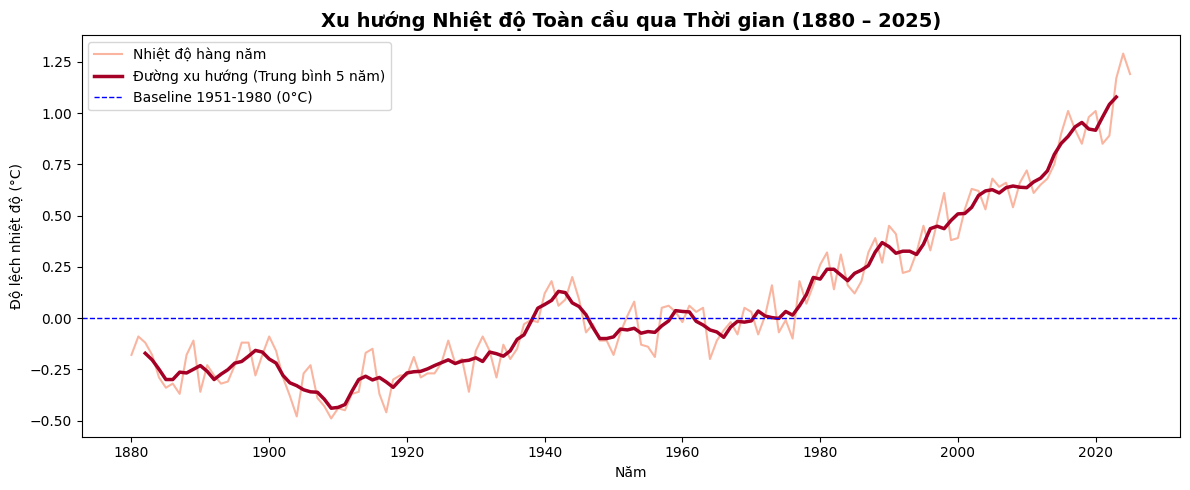

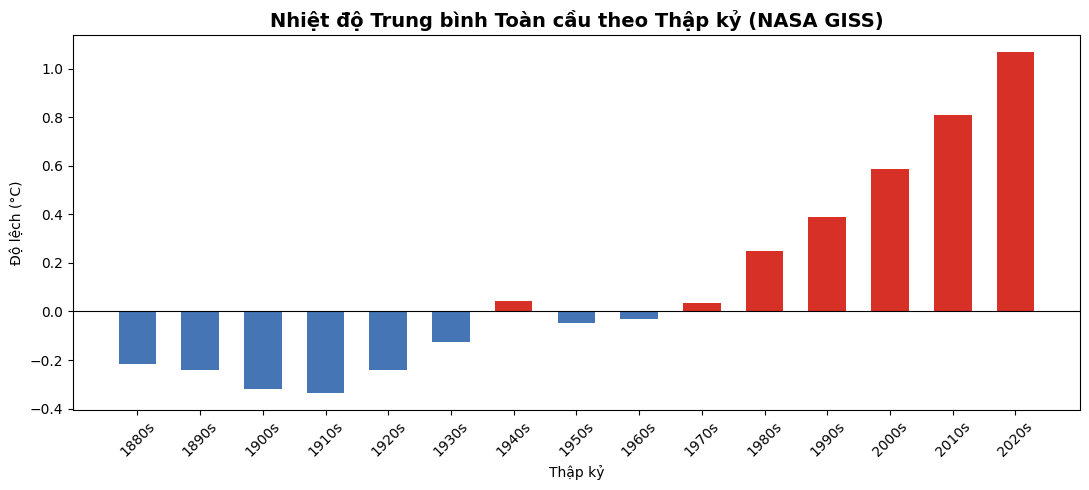

In [ ]:
# 1. Line chart: Xu hướng nhiệt độ toàn cầu 1880 - 2025
plt.figure(figsize=(12, 5))
plt.plot(df_nasa_final['year'], df_nasa_final['temperature_anomaly'], color='#f46d43', alpha=0.5, label='Nhiệt độ hàng năm')
df_nasa_final['rolling_5'] = df_nasa_final['temperature_anomaly'].rolling(5, center=True).mean()
plt.plot(df_nasa_final['year'], df_nasa_final['rolling_5'], color='#a50026', linewidth=2.5, label='Đường xu hướng (Trung bình 5 năm)')
plt.axhline(0, color='blue', linestyle='--', linewidth=1, label='Baseline 1951-1980 (0°C)')
plt.title('Xu hướng Nhiệt độ Toàn cầu qua Thời gian (1880 – 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Độ lệch nhiệt độ (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('eda/duc/bieu_do_tinh/01_xu_huong_nhiet_do_toan_cau.png', dpi=300)
plt.show()

# 2. Bar chart: Nhiệt độ trung bình theo thập kỷ
df_dec = df_nasa_final.groupby('decade')['temperature_anomaly'].mean().reset_index()
colors = ['#4575b4' if v < 0 else '#d73027' for v in df_dec['temperature_anomaly']]
plt.figure(figsize=(11, 5))
plt.bar(df_dec['decade'].astype(str) + 's', df_dec['temperature_anomaly'], color=colors, width=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Nhiệt độ Trung bình Toàn cầu theo Thập kỷ (NASA GISS)', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Độ lệch (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda/duc/bieu_do_tinh/02_nhiet_do_theo_thap_ky.png', dpi=300)
plt.show()


#### 3. Heatmap (Châu lục x Thập kỷ) & 4. Boxplot (Phân bố nhiệt độ quốc gia)

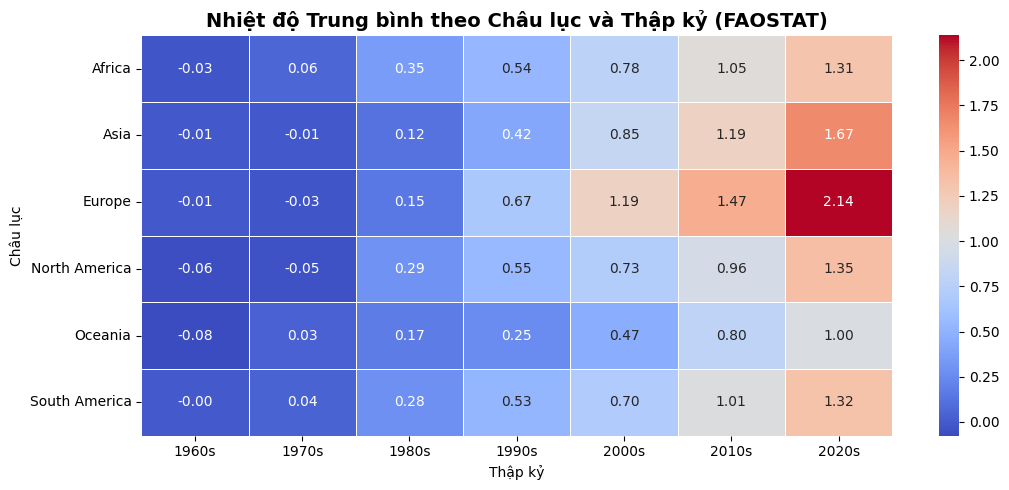

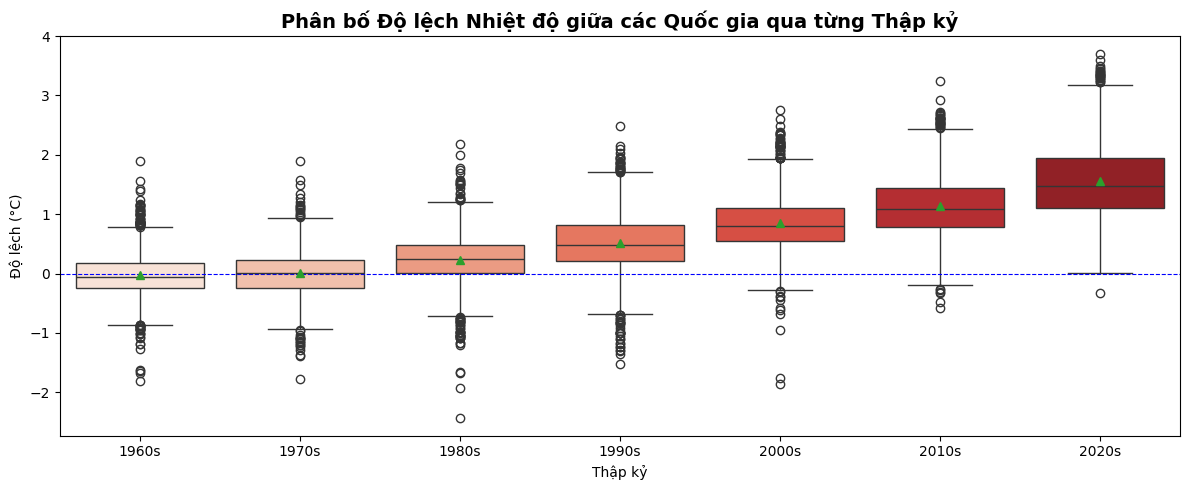

In [7]:
# 3. Heatmap: Nhiệt độ theo Châu lục x Thập kỷ
pivot_cont = df_fao_final.pivot_table(index='continent', columns='decade', values='temperature_anomaly', aggfunc='mean')
pivot_cont.columns = [f'{c}s' for c in pivot_cont.columns]
plt.figure(figsize=(11, 5))
sns.heatmap(pivot_cont, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Nhiệt độ Trung bình theo Châu lục và Thập kỷ (FAOSTAT)', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Châu lục')
plt.tight_layout()
plt.savefig('eda/duc/bieu_do_tinh/04_heatmap_chau_luc_thap_ky.png', dpi=300)
plt.show()

# 4. Boxplot: Phân bố nhiệt độ giữa các quốc gia
plt.figure(figsize=(12, 5))
df_fao_final['decade_str'] = df_fao_final['decade'].astype(str) + 's'
sns.boxplot(data=df_fao_final, x='decade_str', y='temperature_anomaly', hue='decade_str', palette='Reds', showmeans=True, legend=False)
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8)
plt.title('Phân bố Độ lệch Nhiệt độ giữa các Quốc gia qua từng Thập kỷ', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Độ lệch (°C)')
plt.tight_layout()
plt.savefig('eda/duc/bieu_do_tinh/05_phan_bo_nhiet_do_quoc_gia.png', dpi=300)
plt.show()


#### 5. Choropleth Map (Bản đồ nhiệt độ thế giới)

In [8]:
df_2024 = df_fao_final[df_fao_final['year'] == 2024].dropna(subset=['temperature_anomaly'])
fig = px.choropleth(
    df_2024,
    locations='iso_alpha',
    color='temperature_anomaly',
    hover_name='country',
    color_continuous_scale='RdBu_r',
    range_color=[-1.5, 3.5],
    title='Bản đồ Độ lệch Nhiệt độ Thế giới năm 2024 (so với 1951–1980)',
    labels={'temperature_anomaly': 'Độ lệch (°C)'},
    template='plotly_white'
)
fig.write_html('eda/duc/bieu_do_tuong_tac/03_ban_do_nhiet_do.html')
fig.write_image('eda/duc/bieu_do_tinh/03_ban_do_nhiet_do.png', scale=2)
fig.show()
